# Coin Detection, Classification, and Counting — Solution

Standalone solution notebook (the brief lives in `assignment_module_one.ipynb`).
The pipeline factors into five blocks **A–E** (see `Strategy.md`). The notes below
are provisional (*what / why / how*), to be turned into final prose later. Each
decision is anchored to the relevant chapter of `IPCV_Part1_Summary_v2.pdf`.

## 0. Setup

- **What.** Imports, dataset paths, the physical coin grid (diameters and values), and display helpers.
- **Why.** Local execution (dataset extracted under `./coin_dataset`); consistent BGR->RGB handling.
- **How.** `cv2`/`numpy`/`matplotlib`; `DIAMETER_MM` is the physical ground truth block C fits to.
- **Theory.** -- (engineering).

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Local setup: dataset extracted under ./coin_dataset (from coin_dataset.zip).
DATA = Path("coin_dataset")
REF, TGT = DATA / "reference_set", DATA / "target_set"

# Physical euro-coin diameters (mm) and face values: the ground truth used downstream.
DIAMETER_MM = {"1cent": 16.25, "2cent": 18.75, "5cent": 21.25, "10cent": 19.75,
               "20cent": 22.25, "50cent": 24.25, "1euro": 23.25, "2euro": 25.75}
VALUE_EUR   = {"1cent": 0.01, "2cent": 0.02, "5cent": 0.05, "10cent": 0.10,
               "20cent": 0.20, "50cent": 0.50, "1euro": 1.00, "2euro": 2.00}

def load_rgb(path):
    bgr = cv2.imread(str(path))
    assert bgr is not None, f"imread failed: {path}"
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def show_row(images, titles, figsize=None):
    n = len(images)
    plt.figure(figsize=figsize or (4 * n, 4))
    for i, (img, t) in enumerate(zip(images, titles), 1):
        plt.subplot(1, n, i)
        (plt.imshow(img, cmap="gray", vmin=0, vmax=255) if img.ndim == 2 else plt.imshow(img))
        plt.title(t, fontsize=10); plt.axis("off")
    plt.tight_layout(); plt.show()

print("cv2", cv2.__version__, "| refs", len(list(REF.glob("*.jpg"))),
      "| targets", len(list(TGT.glob("*.jpg"))))

cv2 4.13.0 | refs 8 | targets 142


## 1. Pre-processing — image filtering (Summary §3)

- **What.** Convert to grayscale and evaluate the cap. 3.4 denoising filters on the coin images.
- **Why.** Detection is noise-sensitive, and target images are genuinely noisy (sigma ~ 17) while reference images are clean (sigma ~ 0.3). We must decide whether/what to smooth. Finding: denoising does **not** remove the blue colour cast (it is specular reflection, not noise), so filtering is a detection pre-step only, never a classification cue.
- **How.** Robust noise estimate (Immerkåer); apply the five Table-1 filters and compare. The chosen detector (block B, LoG) folds smoothing into its scale-space, so no separate pre-filter is applied; had we used Hough, a Gaussian (sigma ~ 2) would be the choice.
- **Theory.** Summary §3.3 (mean, Gaussian — separable, sigma sets the scale); §3.4 (median, bilateral, non-local means; Table 1).

noise sigma  reference=0.26  target=17.59


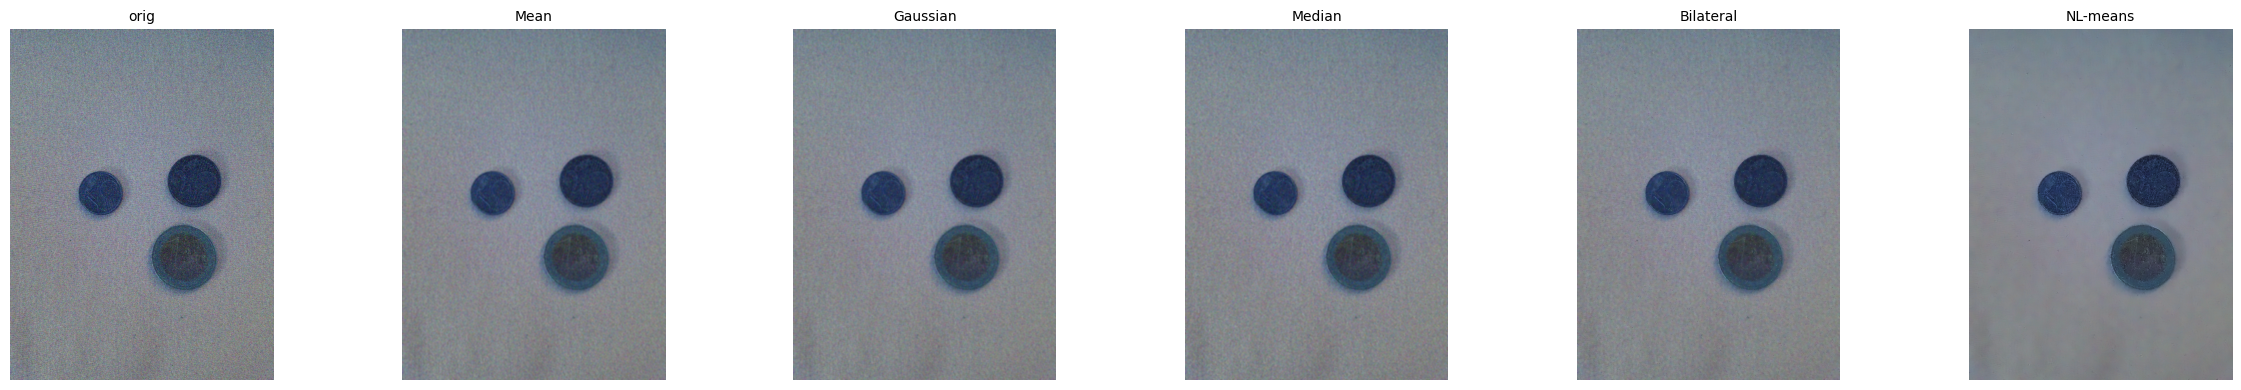

In [2]:
# Robust noise level (Immerkaer) on a flat background corner: insensitive to gradients.
def noise_sigma(gray):
    M = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], float)
    h, w = gray.shape
    return np.sqrt(np.pi / 2) / (6 * (w - 2) * (h - 2)) * np.abs(
        cv2.filter2D(gray.astype(float), -1, M)).sum()

ref_g = cv2.cvtColor(load_rgb(REF / "1euro.jpg"), cv2.COLOR_RGB2GRAY)
tgt_g = cv2.cvtColor(load_rgb(TGT / "image_133.jpg"), cv2.COLOR_RGB2GRAY)
print(f"noise sigma  reference={noise_sigma(ref_g[:120, :120]):.2f}  "
      f"target={noise_sigma(tgt_g[:120, :120]):.2f}")

# cap. 3.4 / Table 1 denoising filters (work in BGR, show in RGB).
def apply_filters(rgb):
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    out = {"Mean": cv2.blur(bgr, (5, 5)),
           "Gaussian": cv2.GaussianBlur(bgr, (0, 0), 1.5),
           "Median": cv2.medianBlur(bgr, 5),
           "Bilateral": cv2.bilateralFilter(bgr, 9, 75, 75),
           "NL-means": cv2.fastNlMeansDenoisingColored(bgr, None, 10, 10, 7, 21)}
    return {k: cv2.cvtColor(v, cv2.COLOR_BGR2RGB) for k, v in out.items()}

t = load_rgb(TGT / "image_133.jpg")
f = apply_filters(t)
show_row([t] + list(f.values()), ["orig"] + list(f.keys()), figsize=(24, 4))

## 2. Detection — coins as scale-space blobs (Summary §5.4, §4, §6.3)

- **What.** Locate every coin in the image as a centre and radius `(cx, cy, r)`.
- **Why.** Detection must precede classification, and the radius is the key downstream cue: within one image the radius **ratios** are metric (coins share camera distance and pose), even though absolute pixel radius is not.
- **How.** LoG scale-space blob detector: a coin is a dark blob on a lighter background, so the scale-normalized Laplacian of Gaussian `sigma^2 * Laplacian(L)` peaks at the coin centre, and the sigma of the peak gives `r = sqrt(2) * sigma`. Chosen over `cv2.HoughCircles` (§6.3): it detected a low-contrast coin Hough missed, returns the radius for free, needs no separate smoothing, and is immune to the target noise (gone at coin scale).
- **Theory.** Summary §5.4 (scale-space, LoG, Difference of Gaussian); §4 (edges as derivatives); §6.3 (Hough transform — the considered alternative).

detected 3 coins | radii (px) [65, 72, 88] | ratios [0.74, 0.82, 1.0]


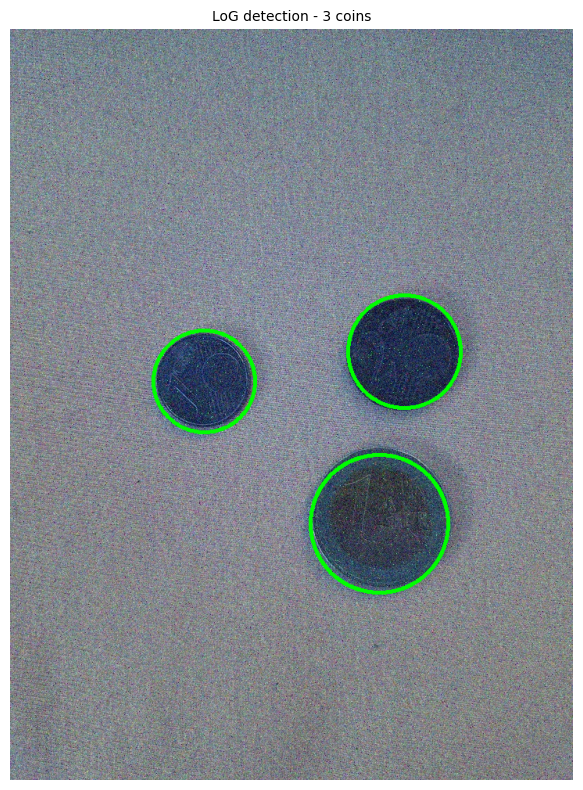

In [3]:
# LoG scale-space blob detector (cap. 5.4). Dark blobs -> maxima of sigma^2 * Laplacian(L).
def log_blobs(gray, smin=25, smax=115, n=16, thr_rel=0.30, min_dist=55):
    g = gray.astype(np.float64)
    scales = np.geomspace(smin, smax, n)
    stack = np.stack([(s ** 2) * cv2.Laplacian(cv2.GaussianBlur(g, (0, 0), s),
                                               cv2.CV_64F, ksize=3) for s in scales])
    maxproj, args = stack.max(0), stack.argmax(0)
    win = np.ones((2 * min_dist + 1,) * 2, np.uint8)
    peaks = (maxproj == cv2.dilate(maxproj, win)) & (maxproj > thr_rel * maxproj.max())
    ys, xs = np.where(peaks)
    blobs = []
    for _, x, y in sorted(zip(maxproj[ys, xs], xs, ys), reverse=True):
        if all((x - bx) ** 2 + (y - by) ** 2 > min_dist ** 2 for bx, by, _ in blobs):
            blobs.append((int(x), int(y), float(np.sqrt(2) * scales[args[y, x]])))
    return blobs

rgb = load_rgb(TGT / "image_133.jpg")
blobs = log_blobs(cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY))
vis = rgb.copy()
for x, y, r in blobs:
    cv2.circle(vis, (x, y), int(r), (0, 255, 0), 3)
radii = sorted(round(r) for _, _, r in blobs)
print("detected", len(blobs), "coins | radii (px)", radii,
      "| ratios", [round(r / max(radii), 2) for r in radii])
show_row([vis], [f"LoG detection - {len(blobs)} coins"], figsize=(6, 8))

## C. Classification — geometry-first joint inference (Summary §6, §5)

- **What.** Map each detected `(cx, cy, r)` to a denomination in {1c, 2c, 5c, 10c, 20c, 50c, 1€, 2€}.
- **Why.** The hardest block. Absolute colour is dead (strong blue specular cast on the target set) and absolute radius is not metric (camera distance varies). SIFT matching against the reference is weak (not diagonal-dominant; ~50% two-sides recall).
- **How.** **Not yet implemented.** Planned: per image, fit a single scale `s` (px/mm) mapping the detected radii onto the physical `DIAMETER_MM` grid, anchored by a structurally-detected bi-metallic coin (radial profile) or by constellation self-consistency. Within-family size gaps are wide (>= 2 mm); the residual ~1 mm collisions are all cross-family.
- **Theory.** Summary §6 (instance-level object detection), §6.1 (template matching); §5 (local invariant features — parked: SIFT weak here).

In [4]:
# NOT YET IMPLEMENTED — block C.
# Planned: geometry-first joint inference (relative radius -> scale-grid fit), with a
# bi-metallic coin or the radius constellation fixing the per-image scale s (px/mm).
def classify_coins(blobs, image_rgb):
    raise NotImplementedError("block C: scale-grid fit over DIAMETER_MM (to build)")

## D. Aggregation and output (brief format)

- **What.** Per image: list each coin and the `Partial Amount`; across the dataset: the `Total Amount`.
- **Why.** The brief fixes the output format exactly; getting it right is part of the grade.
- **How.** Sum the face values from `VALUE_EUR` and print `Coin N {value: X.XXX}`, `Partial Amount {value: ...}`, and a final `Total Amount: ... €`.
- **Theory.** -- (arithmetic + formatting).

In [5]:
# Output formatting fixed by the brief.
def format_image_result(image_name, denominations):
    lines = [f"{image_name} - {len(denominations)} coin(s) found:"]
    total = 0.0
    for i, d in enumerate(denominations, 1):
        total += VALUE_EUR[d]
        lines.append(f"  Coin {i} {{value: {VALUE_EUR[d]:.3f}}}")
    lines.append(f"  Partial Amount {{value: {total:.3f}}}")
    return "\n".join(lines), total

# Demo on placeholder denominations (block C will produce the real ones).
demo, partial = format_image_result("image_133.jpg", ["10cent", "20cent", "1euro"])
print(demo)
print("...\nTotal Amount: TBD €")

image_133.jpg - 3 coin(s) found:
  Coin 1 {value: 0.100}
  Coin 2 {value: 0.200}
  Coin 3 {value: 1.000}
  Partial Amount {value: 1.300}
...
Total Amount: TBD €


## E. Calibration on the reference set

- **What.** Derive the constants/templates that blocks A–C consume from the 8 labelled reference images.
- **Why.** With no learned model, the parameters must come from the labelled data; this is a methodology step, not a runtime block.
- **How.** Colour is unusable (cast) and absolute radius is not metric across shots, so the physical `DIAMETER_MM` grid is the ground truth block C fits to. Here we measure the reference radii as a sanity prior; the bi-metallic radial-profile template (1€/2€) is to be added.
- **Theory.** -- (methodology; drives the closures recorded in `Strategy.md` §5).

In [6]:
# Reference radii (single coin per image) as a sanity prior — not a metric calibration.
for name in ["1cent", "5cent", "1euro", "2euro"]:
    g = cv2.cvtColor(load_rgb(REF / f"{name}.jpg"), cv2.COLOR_RGB2GRAY)
    b = log_blobs(g, smin=25, smax=130, min_dist=200)
    r = b[0][2] if b else float("nan")
    print(f"{name:7s} reference radius ~ {r:5.0f} px   (physical diameter {DIAMETER_MM[name]} mm)")

1cent   reference radius ~    61 px   (physical diameter 16.25 mm)


5cent   reference radius ~    68 px   (physical diameter 21.25 mm)


1euro   reference radius ~    95 px   (physical diameter 23.25 mm)


2euro   reference radius ~    85 px   (physical diameter 25.75 mm)
